#Big Data & Data Mining — Studi Kasus: Klasifikasi Rentang Harga Smartphone Berdasarkan Spesifikasi Teknik

- **Nama:** Satrio Raja Nabil Rizky
- **NIM:** 23.11.5538
- **Class:** IF-03


Tujuan: Memprediksi apakah sebuah handphone masuk kategori harga "Low Cost" atau "Expensive" berdasarkan fitur seperti RAM, Baterai, Kamera, dll.

# BAGIAN 1: PROFILE DATASET


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


local_path = "/content/train.csv"

try:
    df = pd.read_csv(local_path)
    print("Berhasil memuat dataset dari file lokal!")
    print(f"\nDimensi Data: {df.shape[0]} Baris, {df.shape[1]} Kolom")
    display(df.head())
except Exception as e:
    print(f"Gagal memuat data dari file lokal: {e}")

Berhasil memuat dataset dari file lokal!

Dimensi Data: 2000 Baris, 21 Kolom


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


# BAGIAN 2: DATA PREPROCESSING


In [41]:
print("\n--- MULAI PREPROCESSING ---")

# 1. TARGET MAPPING (Simplifikasi Kategori)

df['price_binary'] = df['price_range'].map({0:0, 1:0, 2:1, 3:1})

# 2. SELEKSI FITUR
X = df.drop(['price_range', 'price_binary'], axis=1)
y = df['price_binary']

print(f"Jumlah Fitur Final (X): {X.shape[1]} Kolom")
print("Preprocessing Selesai.")


--- MULAI PREPROCESSING ---
Jumlah Fitur Final (X): 20 Kolom
Preprocessing Selesai.


# BAGIAN 3: EXPLORATORY DATA ANALYSIS (EDA)


/tmp/ipython-input-3798048977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_binary', y='ram', data=df, palette='viridis')
/tmp/ipython-input-3798048977.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='price_binary', y='battery_power', data=df, palette='magma')


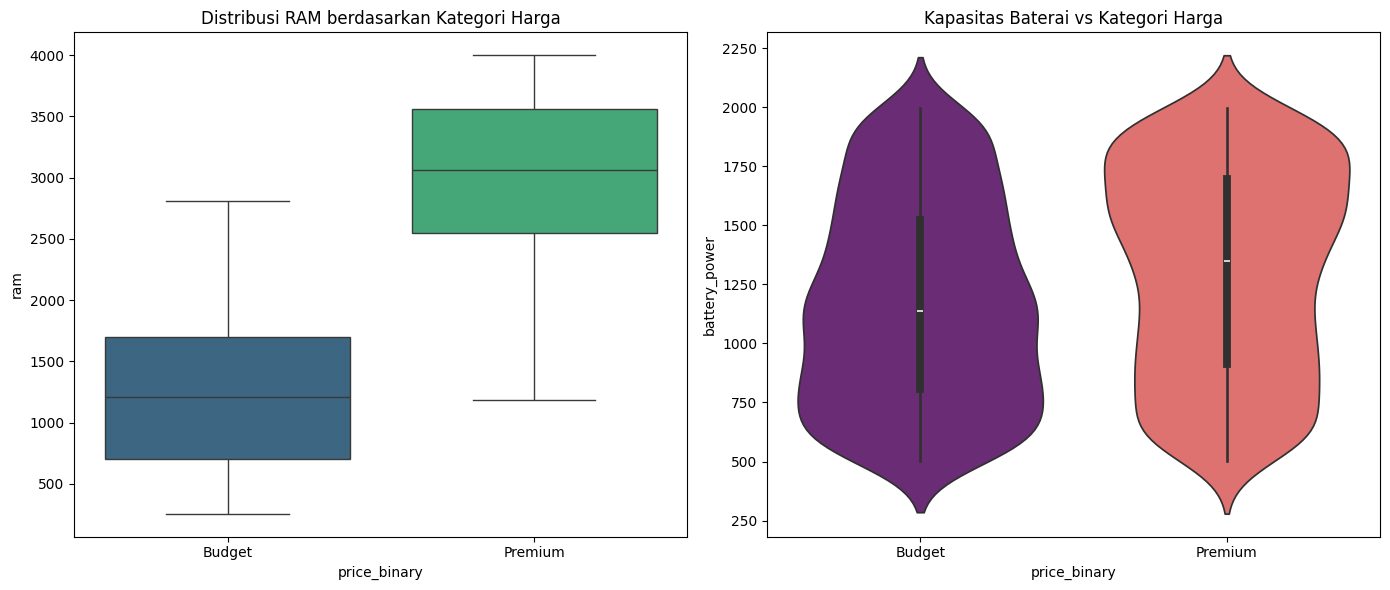

Interpretasi EDA: RAM menunjukkan perbedaan yang sangat kontras antara kategori Budget dan Premium.


In [42]:

plt.figure(figsize=(14, 6))

# Visualisasi 1: Pengaruh RAM terhadap Kategori Harga
plt.subplot(1, 2, 1)
sns.boxplot(x='price_binary', y='ram', data=df, palette='viridis')
plt.title('Distribusi RAM berdasarkan Kategori Harga')
plt.xticks([0, 1], ['Budget', 'Premium'])

# Visualisasi 2: Hubungan Kapasitas Baterai dengan Harga
plt.subplot(1, 2, 2)
sns.violinplot(x='price_binary', y='battery_power', data=df, palette='magma')
plt.title('Kapasitas Baterai vs Kategori Harga')
plt.xticks([0, 1], ['Budget', 'Premium'])

plt.tight_layout()
plt.show()

print("Interpretasi EDA: RAM menunjukkan perbedaan yang sangat kontras antara kategori Budget dan Premium.")

# BAGIAN 4 & 5: MODELING

Sedang melatih model Random Forest...


/tmp/ipython-input-2768778940.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp, y=feature_imp.index, palette='coolwarm')


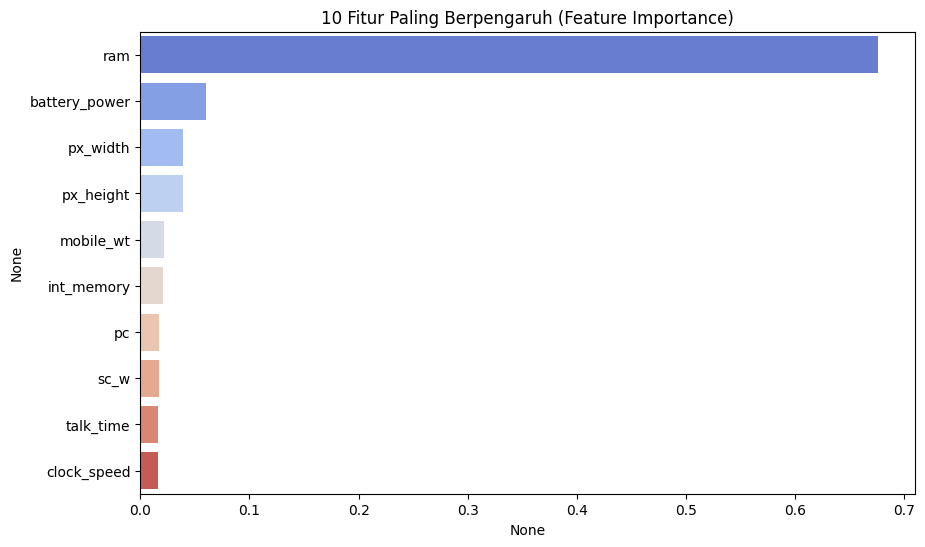

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Sedang melatih model Random Forest...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
rf_model.fit(X_train, y_train)

# Visualisasi Fitur Terpenting

feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp, y=feature_imp.index, palette='coolwarm')
plt.title('10 Fitur Paling Berpengaruh (Feature Importance)')
plt.show()

# BAGIAN 6: EVALUASI PERFORMA


AKURASI MODEL: 96.50%


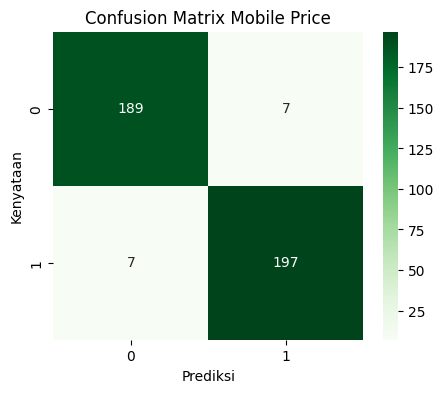


--- DETAIL LAPORAN KLASIFIKASI ---
              precision    recall  f1-score   support

      Budget       0.96      0.96      0.96       196
     Premium       0.97      0.97      0.97       204

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [44]:
y_pred = rf_model.predict(X_test)

print("="*40)
print(f"AKURASI MODEL: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("="*40)

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix Mobile Price')
plt.ylabel('Kenyataan')
plt.xlabel('Prediksi')
plt.show()

print("\n--- DETAIL LAPORAN KLASIFIKASI ---")
print(classification_report(y_test, y_pred, target_names=['Budget', 'Premium']))

In [37]:
# Simpan Model
joblib.dump(rf_model, 'model_mobile_price.pkl')
print("\nModel disimpan: model_mobile_price.pkl")


Model disimpan: model_mobile_price.pkl
